In [20]:
import sys, os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from cycler import cycler
from matplotlib.ticker import ScalarFormatter

from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))
from im_net import datamanager, plotting
import datareader

plot_path = "./figures/Figure5"
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})

pid_palette = ['#ea535a', '#0066ac', '#9a26c8', '#eebbee', '#cadce0']
paper_palette = ['#1a1a1aff', '#d0a807ff', '#406ee1ff', '#c93b9bff', '#1dbd68ff']
performance_palette = sns.color_palette('husl')
sns.set_palette(performance_palette)

# Critical memory loads
alpha_h = 0.14
alpha_red = 1.59

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Figure 5: Comparison with Classical Learning Rules

This figure benchmarks infomorphic learning against classical Hopfield learning rules:
- **Hebbian** learning
- **Descent L2**: gradient descent with L2 loss
- **MPF**: Minimum Probability Flow
- **Infomorphic** rules: redundancy goal $G=\Pi_{\mathrm{red}}$ and optimised goal

In [21]:
def load_eval_runs(file):
    """Load runs evaluated via eval_rule.py (returns capacity array)."""
    dm = datamanager.DataManager(file, mode='analysis', add_run_properties=True, verbose=0)
    seeds = dm.sel['params.seed']
    n_reps = len(set(seeds))
    m_patterns = datareader.group_data_to_numpy(dm, 'capacity', 'patterns')
    n_neurons = dm.sel['params.neurons']
    x_alpha = m_patterns[0] / n_neurons[0]
    acc = datareader.group_data_to_numpy(dm, 'capacity', 'acc')
    acc = acc.T
    return dm, x_alpha, acc


def boundary(file, epsilon=0.95):
    """Compute the noise stability boundary from a pickle file of recall results."""
    with open(file, 'rb+') as f:
        results = pickle.load(f)
        boundaries = []
        for k in range(results.shape[-1]):  # runs
            boundary_k = []
            for i in range(results.shape[0]):  # network size
                for j in range(results.shape[1]):  # flips
                    if results[i, 0, k] < epsilon:
                        boundary_k.append(0)
                        break
                    elif (results[i, j, k] > epsilon) and (np.mean(results[i, j:j+5, k]) < epsilon):
                        boundary_k.append(j)
                        break
                    elif j == (results.shape[1] - 1):
                        boundary_k.append(j)
                        break
            boundaries.append(boundary_k)
        results = np.array(results)
        boundaries = np.array(boundaries).T
        return results, boundaries

## Panel A: Recall Accuracy

Recall accuracy as a function of memory load for all learning rules.

**Training commands:**
```bash
# Infomorphic rules
python src/training.py -m goal=optimized goal/candidates=d \
    +mods/capacity=paper params.seed='range(20)' params.epochs=5000

# Classical rules (MPF, Descent L2)
python src/eval_rule.py -m params.seed='range(20)' learning_rule=mpf,descent_l2
```

In [ ]:
# TODO: set paths to Panel A experiment folders
file_redundancy = ''
file_optimized_i = ''
file_hebb = ''
file_descent_l2 = ''
file_mpf = ''

_, x_alpha_all, acc_redundancy = datareader.load_capacity_runs(file_redundancy)
_, _, acc_optimized_i = datareader.load_capacity_runs(file_optimized_i)
_, _, acc_l2 = load_eval_runs(file_descent_l2)
_, _, acc_mpf = load_eval_runs(file_mpf)
_, _, acc_hebb = load_eval_runs(file_hebb)
x_alpha = x_alpha_all[0]
print(f"Loaded Panel A data: {len(x_alpha)} alpha values, {acc_redundancy.shape[0]} seeds.")

Loaded Panel A data: 41 alpha values, 20 seeds.


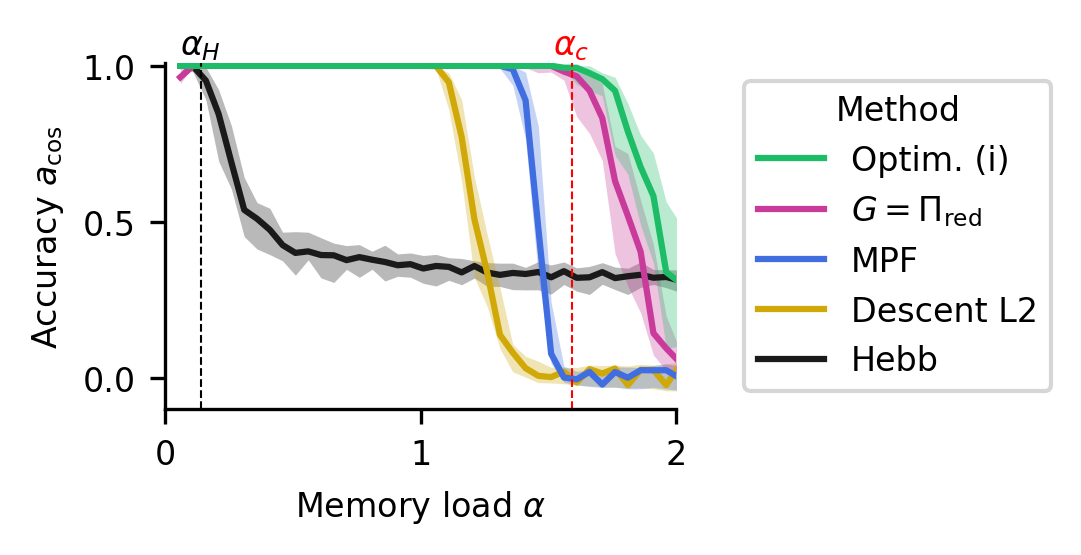

In [23]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=paper_palette)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Accuracy $a_{\mathrm{cos}}$')

plotting.plot_mean_and_area(ax, x_alpha[1:], acc_hebb[1:], label='Hebb', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha[1:], acc_l2[1:], label='Descent L2', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha[1:], acc_mpf[1:], label='MPF', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha[1:], acc_redundancy[:, 1:], mean_ax=0,
                            label=r'$G=\Pi_{\mathrm{red}}$', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha[1:], acc_optimized_i[:, 1:], mean_ax=0,
                            label=r'Optim. (i)', quantile=0.9, median=True)

ax.text(alpha_h, 1 + 0.012, r'$\alpha_H$', horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_red, 1 + 0.012, r'$\alpha_{c}$',
        horizontalalignment='center', verticalalignment='bottom', c='r')
ax.vlines(alpha_h, -0.1, 1.1, 'k', '--', linewidth=0.5)
ax.vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=True, border_y=(0.1, 0.01))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1.1, 0.5), title='Method')
ax.xaxis.set_major_formatter(ScalarFormatter())
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/capacity_comparison.svg", bbox_inches='tight')

# Panel B: Threshold Recall Accuracy

Same comparison using threshold-based accuracy $a_\theta$ instead of cosine similarity.

**Training command:**
```bash
python src/training.py +mods/capacity=paper goal/candidates=g goal=optimized \
    params.epochs=5000 params.seed='range(20)' \
    storage.testing.threshold_test=True storage=cluster
```

In [ ]:
# TODO: set paths to threshold metric experiment folders
file_redundancy_th = '' 
file_optimized_i_th = ''
file_hebb_th = ''
file_descent_exp_th = ''
file_descent_l2_th = ''
file_mpf_th = ''

_, x_alpha_all_th, acc_redundancy_th = datareader.load_capacity_runs(file_redundancy_th)
_, _, acc_optim_i_th = datareader.load_capacity_runs(file_optimized_i_th)
_, _, acc_hebb_th = load_eval_runs(file_hebb_th)
_, _, acc_l2_th = load_eval_runs(file_descent_l2_th)
_, _, acc_mpf_th = load_eval_runs(file_mpf_th)
x_alpha_th = x_alpha_all_th[0]
print(f"Loaded threshold data: {len(x_alpha_th)} alpha values, {acc_redundancy_th.shape[0]} seeds.")

Loaded threshold data: 41 alpha values, 20 seeds.


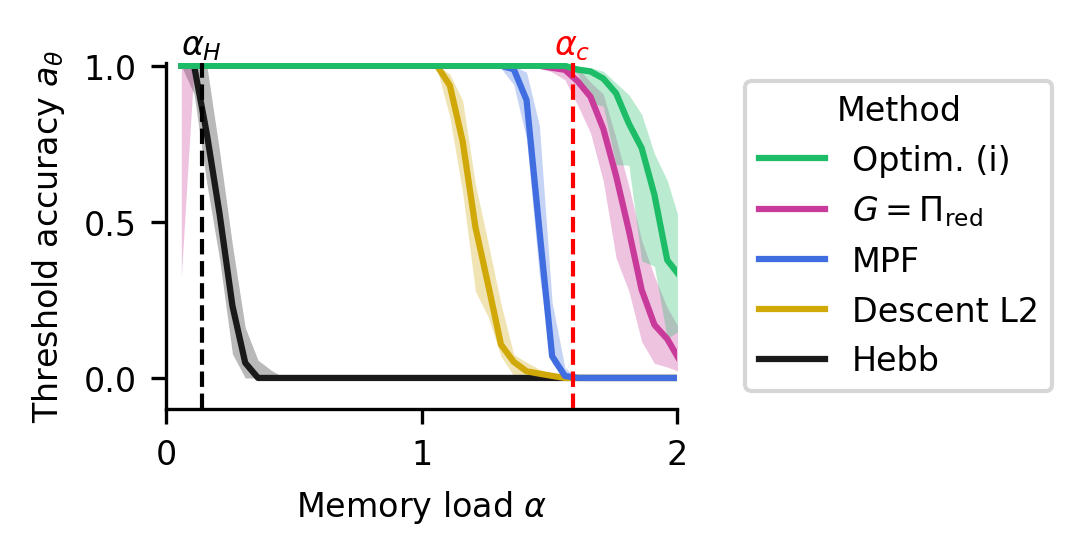

In [25]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=paper_palette)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Threshold accuracy $a_\theta$')

plotting.plot_mean_and_area(ax, x_alpha_th[1:], acc_hebb_th[1:], label='Hebb', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha_th[1:], acc_l2_th[1:], label='Descent L2', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha_th[1:], acc_mpf_th[1:], label='MPF', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha_th[1:], acc_redundancy_th[:, 1:], mean_ax=0,
                            label=r'$G=\Pi_{\mathrm{red}}$', quantile=0.9, median=True)
plotting.plot_mean_and_area(ax, x_alpha_th[1:], acc_optim_i_th[:, 1:], mean_ax=0,
                            label=r'Optim. (i)', quantile=0.9, median=True)

ax.vlines(alpha_h, -0.1, 1.1, 'k', '--', linewidth=1)
ax.vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=1)
ax.text(alpha_h, 1 + 0.012, r'$\alpha_H$', horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_red, 1 + 0.012, r'$\alpha_{c}$',
        horizontalalignment='center', verticalalignment='bottom', c='r')

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=True, border_y=(0.1, 0.01))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1.1, 0.5), title='Method')
ax.xaxis.set_major_formatter(ScalarFormatter())
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/capacity_threshold.svg", bbox_inches='tight')

## Panel C: Noise Resistance

Maximum flip fraction $f_{\mathrm{max}}$ a stored pattern can tolerate and still be recovered,
as a function of memory load. Data generated using the Hopfield simulator from Tolmachev et al.

**Training command:**
```bash
# See https://github.com/markbluemel02/Hopfield_Nets
python simulations.py
```

In [ ]:
# TODO: set paths to noise resistance experiment pickle files
root_folder = ''
hebb_file = root_folder + '/flips_and_patterns_Hebb_incremental=False_sc=False_100x201x20.pkl'
redundancy_file = root_folder +  '/flips_and_patterns_Infomorphic_sc=False_lr=0.05_maxiter=5000_goal=[0, 0, 1, 0, 0]_symmetric=False_100x201x20.pkl'
optimized_i_file = root_folder + '/flips_and_patterns_Infomorphic_sc=False_lr=0.05_maxiter=5000_goal=[-0.27, -0.68, 0.68, -0.77, -0.8]_symmetric=False_100x201x20.pkl'
descent_l2_file = root_folder + '/flips_and_patterns_DescentL2_sc=False_incremental=False_tol=0.001_lmbd=0.5_alpha=0.001_100x201x20.pkl'
mpf_file = root_folder + '/flips_and_patterns_MPF_sc=False_lr=0.08_maxiter=40000_100x201x20.pkl'


results_hebb, boundary_hebb = boundary(hebb_file)
results_red, boundary_red = boundary(redundancy_file)
results_optim, boundary_optim = boundary(optimized_i_file)
results_mpf, boundary_mpf = boundary(mpf_file)
_, boundary_l2 = boundary(descent_l2_file)
x_noise = np.linspace(1, 201, 41) / 100
print(f"Loaded noise resistance data: {len(x_noise)} alpha values, {boundary_hebb.shape[1]} seeds.")

Loaded noise resistance data: 41 alpha values, 20 seeds.


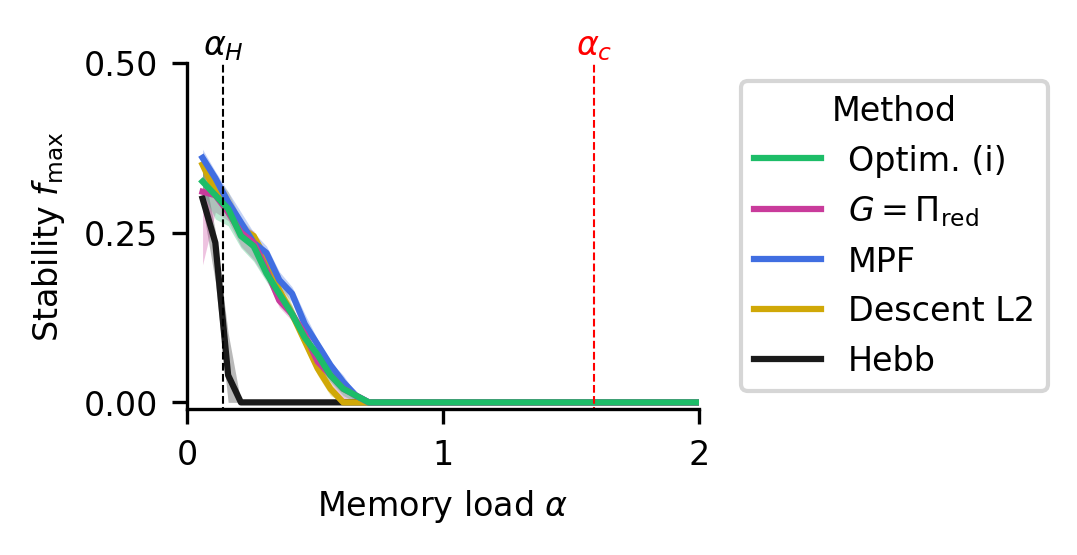

In [30]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=paper_palette)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Stability $f_{\mathrm{max}}$')

plotting.plot_mean_and_area(ax, x_noise[1:], boundary_hebb[1:] / 100, mean_ax=1,
                            quantile=0.5, label='Hebb', median=True)
plotting.plot_mean_and_area(ax, x_noise[1:], boundary_l2[1:] / 100, mean_ax=1,
                            quantile=0.5, label='Descent L2', median=True)
plotting.plot_mean_and_area(ax, x_noise[1:], boundary_mpf[1:] / 100, mean_ax=1,
                            quantile=0.5, label='MPF', median=True)
plotting.plot_mean_and_area(ax, x_noise[1:], boundary_red[1:] / 100, mean_ax=1,
                            quantile=0.5, label=r'$G=\Pi_{\mathrm{red}}$', median=True)
plotting.plot_mean_and_area(ax, x_noise[1:], boundary_optim[1:] / 100, mean_ax=1,
                            quantile=0.5, label=r'Optim. (i)', median=True)

ax.vlines(alpha_h, -0.1, 50.1, 'k', '--', linewidth=0.5)
ax.vlines(alpha_red, -0.1, 50.1, 'r', '--', linewidth=0.5)
ax.text(alpha_h, 0.5 + 0.0002, r'$\alpha_H$', horizontalalignment='center', verticalalignment='bottom')
ax.text(alpha_red, 0.5 + 0.0002, r'$\alpha_{c}$',
        horizontalalignment='center', verticalalignment='bottom', c='r')

plotting.layout_performance(ax, x_lim=(0, 2), y_lim=(0, 0.5), show_legend=True,
                            border_x=(0, 0), border_y=(0.01, 0.))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1.05, 0.5), title='Method')
ax.xaxis.set_major_formatter(ScalarFormatter())
for loc, spine in ax.spines.items():
    if loc in ['right', 'top']:
        spine.set_color('none')
# fig.savefig(f"{plot_path}/noise_resistance.svg", bbox_inches='tight')